# Amazon Products Data- An Exercise in Network Diagramming <a class="anchor" id="top"></a>

## 🌌 A Cosmic Recommendation Engine

Welcome to the **Amazon Product Universe** — a **fully interactive, 3D, self-organizing galaxy of products** built from the famous [SNAP Amazon co-purchase dataset](https://snap.stanford.edu/data/amazon-meta.html).  

---

## 🚀 What This Project Does

- **Graph-Based Recommendations:**  
  Click a product to instantly highlight its top co-purchased items — a visual “customers also bought” experience.  

- **Self-Organizing Galaxy Layout:**  
  Node2Vec embeddings + PCA produce natural 3D clusters, revealing **constellations of related products**.  

- **Category-Colored Nebulae:**  
  Products are colored by category, forming vibrant **galaxies within the universe**.  

- **Interactive and Animated:**  
  The galaxy rotates, links glow, and recommendation edges **pulse like neural signals** — perfect for intuitive exploration.  

- **Portfolio-Ready Visualizations:**  
  Ideal for **data science portfolios**, **interactive notebooks**, and **GitHub Pages demos**.  

---

## 🛠️ How It Works (The Cosmic Engine)

1. **Load & Parse Data:**  
   SNAP Amazon co-purchase edges + product metadata (`amazon-meta.txt`).  

2. **Graph Construction:**  
   Build a **NetworkX graph** where nodes = products, edges = co-purchases.  

3. **Graph Embeddings:**  
   Node2Vec embeddings encode neighborhood relationships.  

4. **Dimensionality Reduction:**  
   PCA reduces embeddings to 3D space, forming **clusters like star systems**.  

5. **Visualization:**  
   Plotly 3D + Dash produces an **interactive, rotating galaxy**, complete with **pulsing recommendation highlights**.  

6. **Interactive Recommendations:**  
   Clicking a product shows **its co-purchase neighbors** with glowing animated edges — a visual recommender engine in action.  

---

## 🌟 Why This Is Cool

- Makes a **complex co-purchase graph tangible**.  
- Reveals **hidden clusters and product ecosystems** visually.  
- Provides **real-time recommendations** via intuitive 3D interaction.  
- Demonstrates mastery of **graph embeddings, interactive 3D visualization, and data engineering pipelines**.

---

In [132]:
!pip install --upgrade colorcet numpy dash datashader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 15.4 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 22.3 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [datashader] 7/8 [datashader]


In [133]:
# Import libraries
import pandas as pd
import collections
import networkx as nx
import colorcet as cc
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output
import random
import numpy as np
import datashader as ds
import datashader.transfer_functions as tf
from datashader.layout import random_layout, circular_layout, forceatlas2_layout
from datashader.bundling import connect_edges, hammer_bundle

In [135]:
# Function to walk the graph embeddings
def node2vec_walk(G, start_node, walk_length):
    
    walk = [str(start_node)]
    
    for _ in range(walk_length - 1):
        
        cur = int(walk[-1])
        neighbors = list(G.neighbors(cur))
        
        if not neighbors:
            
            break
            
        walk.append(str(random.choice(neighbors)))
        
    return walk

def generate_walks(G, num_walks = 10, walk_length = 20):
    
    walks = []
    nodes = list(G.nodes())
    
    for _ in range(num_walks):
        
        random.shuffle(nodes)
        
        for node in nodes:
            
            walks.append(node2vec_walk(G, node, walk_length))
            
    return walks

# Function to draw figure
def build_figure(selected_node = None, pulse_frame = 0):
    
    marker_sizes = [4]*len(nodes)
    
    highlight_edges_x, highlight_edges_y, highlight_edges_z = [],[],[]
    highlight_nodes = node_colors.copy()
    
    if selected_node is not None:
        
        neighbors = list(G.neighbors(selected_node))[:15]
        
        for n in neighbors:
            
            idx = node_index[n]
            highlight_nodes[idx] = "#ffff00"
            marker_sizes[idx] = 8
            
            x0,y0,z0 = coords[node_index[selected_node]]
            x1,y1,z1 = coords[idx]
            
            # glowing pulse animation
            factor = 0.5 + 0.5 * np.sin(np.radians(pulse_frame * 10))
            
            highlight_edges_x += [x0 * factor + x1 * (1-factor), x1, None]
            highlight_edges_y += [y0 * factor + y1 * (1-factor), y1, None]
            highlight_edges_z += [z0 * factor + z1 * (1-factor), z1, None]
    
    edge_trace = go.Scatter3d(x = edge_x, 
                              y = edge_y, 
                              z = edge_z,
                              mode = "lines",
                              line = dict(width = 0.3, color = "rgba(180,180,255,0.1)"),
                              hoverinfo = "none")
    
    node_trace = go.Scatter3d(x = x, 
                              y = y, 
                              z = z,
                              mode = "markers",
                              marker = dict(size = marker_sizes,
                                            color = highlight_nodes),
                                            text = [str(n) for n in nodes],
                              hoverinfo = "text")
    
    pulse_trace = go.Scatter3d(x = highlight_edges_x,
                               y = highlight_edges_y,
                               z = highlight_edges_z,
                               mode = "lines",
                               line = dict(width = 4,
                                           color = "orange"),
                               hoverinfo = "none")
    
    fig = go.Figure(data=[edge_trace,node_trace,pulse_trace])
    
    fig.update_layout(paper_bgcolor = "black",
                      plot_bgcolor = "black",
                      scene = dict(bgcolor = "black",
                                   xaxis = dict(visible = False),
                                   yaxis = dict(visible = False),
                                   zaxis = dict(visible = False)),
                        margin = dict(l = 0,r = 0,t = 40,b = 0))
    
    return fig

# Function to generate force bundling
def subdivide_edge(p0, p1, segments = 6):
    
    points = []
    
    for i in range(segments + 1):
        
        t = i / segments
        x = p0[0] * (1 - t) + p1[0] * t
        y = p0[1] * (1 - t) + p1[1] * t
        z = p0[2] * (1 - t) + p1[2] * t
        points.append([x, y, z])
        
    return np.array(points)

# Bundling function
def bundle_edges(edge_segments, iterations = 10, strength = 0.1):

    for _ in range(iterations):

        for i in range(len(edge_segments)):
            for j in range(i + 1, len(edge_segments)):

                segA = edge_segments[i]
                segB = edge_segments[j]

                for k in range(1, len(segA)-1):

                    diff = segB[k] - segA[k]

                    edge_segments[i][k] += strength * diff
                    edge_segments[j][k] -= strength * diff

    return edge_segments

# Functions to build network with datashader
def nodesplot(nodes, name = None, canvas = None, cat = None):
    
    canvas = ds.Canvas(**cvsopts) if canvas is None else canvas
    aggregator = None if cat is None else ds.count_cat(cat)
    agg = canvas.points(nodes,'x','y',aggregator)
    
    return tf.spread(tf.shade(agg, cmap = ["#FF3333"]), px = 3, name = name)

def edgesplot(edges, name = None, canvas = None):
    
    canvas = ds.Canvas(**cvsopts) if canvas is None else canvas
    
    return tf.shade(canvas.line(edges, 'x','y', agg = ds.count()), name = name)

def graphplot(nodes, edges, name = "", canvas = None, cat = None):
    
    if canvas is None:
        
        xr = nodes.x.min(), nodes.x.max()
        yr = nodes.y.min(), nodes.y.max()
        canvas = ds.Canvas(x_range=xr, y_range=yr, **cvsopts)

    np = nodesplot(nodes, name + " nodes", canvas, cat)
    ep = edgesplot(edges, name + " edges", canvas)
    
    return tf.stack(ep, np, how = "over", name = name)

In [70]:
# Load the data
edges = pd.read_csv('/Users/anon/Downloads/com-amazon.ungraph.txt', sep = "\t", comment = "#", header = None, names = ["source","target"])

In [71]:
edges.head()

,source,target
0,1,88160
1,1,118052
2,1,161555
3,1,244916
4,1,346495


In [72]:
edges.shape

(925872, 2)

In [73]:
# Extract products
nodes = pd.DataFrame(pd.unique(edges[["source","target"]].values.ravel()), columns = ["productId"])
nodes["label"] = "Product"

In [74]:
nodes.shape

(334863, 2)

In [75]:
nodes.head()

,productId,label
0,1,Product
1,88160,Product
2,118052,Product
3,161555,Product
4,244916,Product


In [76]:
# Read the metadata
products = []

current = {}

# From file
with open("/Users/anon/Downloads/amazon-meta.txt", encoding = "latin1") as f:

    for line in f:

        line = line.strip()

        # start new product
        if line.startswith("Id:"):
            
            if current:
            
                products.append(current)
            
            current = {"id": int(line.split()[1])}

        elif line.startswith("ASIN:"):
        
            current["asin"] = line.split()[1]

        elif line.startswith("title:"):
            
            current["title"] = line.replace("title:", "").strip()

        elif line.startswith("group:"):
            
            current["group"] = line.split()[1]

        elif line.startswith("salesrank:"):
            
            val = line.split()[1]
            current["salesrank"] = int(val) if val.isdigit() else None

        elif line.startswith("similar:"):

            parts = line.split()

            if len(parts) > 2:
                
                current["similar"] = parts[2:]

        elif line == "":
            
            if current:
                
                products.append(current)
                current = {}

# convert to dataframe
products = pd.DataFrame(products)

In [77]:
products.head()

,id,asin,title,group,salesrank,similar
0,0,0771044445,NaN,NaN,NaN,NaN
1,1,0827229534,Patterns of Preaching: A Sermon Sampler,Book,396585.0,"[0804215715, 156101074X, 0687023955, 068707423..."
2,2,0738700797,Candlemas: Feast of Flames,Book,168596.0,"[0738700827, 1567184960, 1567182836, 073870052..."
3,3,0486287785,World War II Allied Fighter Planes Trading Cards,Book,1270652.0,NaN
4,4,0842328327,Life Application Bible Commentary: 1 and 2 Tim...,Book,631289.0,"[0842328130, 0830818138, 0842330313, 084232861..."


In [78]:
products.isnull().sum()

id                0
asin              0
title          5868
group          5868
salesrank      6327
similar      169459
dtype: int64

In [79]:
# Merge the data
products['salesrank'] = products['salesrank'].fillna(0)
nodes1 = nodes.merge(products, left_on = 'productId', right_on = 'id').drop(['id', 'asin', 'similar'], axis = 1)
nodes1['salesrank'] = nodes1['salesrank'].astype(int)

In [80]:
nodes1.head()

,productId,label,title,group,salesrank
0,1,Product,Patterns of Preaching: A Sermon Sampler,Book,396585
1,88160,Product,Handbook of Contemporary Preaching,Book,248633
2,118052,Product,The Four Pages of the Sermon: A Guide to Bibli...,Book,64877
3,161555,Product,Witness of Preaching,Book,93405
4,244916,Product,The Preaching Life,Book,92111


In [118]:
nodes1['group'].value_counts()

group
Book        248916
Music        54824
DVD          15743
Video        15361
Toy              5
Software         2
Sports           1
Name: count, dtype: int64

In [102]:
# Get a sample to reduce memory footprint
sampled_edges = edges.sample(n = 2500, random_state = 100)

In [103]:
# Init the graph
graph = nx.from_pandas_edgelist(sampled_edges, 'source', 'target')

In [106]:
sampled_nodes = list(graph.nodes())
sampled_idx = {node: i for i, node in enumerate(sampled_nodes)}

In [107]:
# Generate the embeddings
walks = generate_walks(graph, num_walks = 100, walk_length = 20)
embedder = Word2Vec(walks, vector_size = 64, window = 10, min_count = 0, sg = 1)
embeddings = np.array([embedder.wv[str(node)] for node in sampled_nodes])

In [108]:
# Get coords through PCA
pca = PCA(n_components = 3)
coords = pca.fit_transform(embeddings)
x, y, z = coords[:,0], coords[:,1], coords[:,2]

In [109]:
# Extract colors from colorcet
colors = [i for i in cc.glasbey]
node_colors = [random.choice(colors) for _ in sampled_nodes]

In [110]:
embeddings[0]

array([ 0.15114155, -0.27042434, -0.59223855,  1.3637967 ,  1.2125313 ,
        0.1828119 ,  0.2831369 , -0.74113166, -0.83528185, -0.24755104,
        0.19393303, -0.4015307 ,  0.29709083, -0.40036193, -0.90152574,
        0.8632396 , -1.2829412 , -0.19286281,  0.2872145 ,  0.84548545,
        0.68471617, -0.01589686,  0.2826212 , -1.3051056 , -0.328441  ,
       -0.1839856 , -0.54962516,  0.1569784 ,  0.03684511, -0.4369377 ,
        0.04674692,  1.1534255 , -0.7161229 , -0.1901524 ,  0.18702556,
       -0.14668173, -0.91177493,  0.45891708,  0.79360825, -0.05910629,
        1.1231881 , -0.9152503 ,  1.7329931 ,  0.09852445, -0.11329029,
        0.8945667 , -0.18831718,  0.40415415,  0.8595183 ,  0.29011375,
       -0.05301199,  0.11830516, -0.923071  ,  0.12259746, -0.3438109 ,
       -0.24374631, -0.57514673, -0.61003643,  0.69792634,  1.5509654 ,
        0.4145084 , -0.32807332,  0.1786175 , -0.64047194], dtype=float32)

In [111]:
node_colors[0:5]

['#ffa52f', '#d60000', '#008e64', '#e1cd9c', '#90a1e9']

In [112]:
# Build graph edges
edge_x, edge_y, edge_z = [], [], []

for edge in graph.edges():
    
    x0, y0, z0 = coords[sampled_idx[edge[0]]]
    x1, y1, z1 = coords[sampled_idx[edge[1]]]
    
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

In [124]:
# Setup the dash config
app = Dash(__name__)
app.layout = html.Div(style = {"backgroundColor":"black"},
                      children = [html.H2("Amazon Shopping Product Networks",
                                          style = {"color":"white",
                                                   "textAlign":"center"}),
                                          dcc.Graph(id = "galaxy",
                                                    figure = build_figure()),
                                                    dcc.Interval(id = "interval", interval = 200, n_intervals = 0)])
    
selected = {"node": None,
            "pulse": 0}

@app.callback(Output("galaxy", "figure"), Input("galaxy", "clickData"), Input("interval", "n_intervals"))

# Function to update graphing
def update(clickData, n_intervals):
    
    if clickData:
        
        selected["node"] = int(clickData["points"][0]["text"])
    
    selected["pulse"] = n_intervals
    
    return build_figure(selected["node"], selected["pulse"])

In [125]:
app.run(debug = True)

In [134]:
# Compile the data
#edge_segments = []

# Iterate
#for u, v in graph.edges():

#    p0 = coords[sampled_idx[u]]
#    p1 = coords[sampled_idx[v]]

#    segments = subdivide_edge(p0, p1, segments = 6)

#    edge_segments.append(segments)

# Apply function to bundle
#bundled_segments = bundle_edges(edge_segments)

# Compile the bundled segments
#edge_x = []
#edge_y = []
#edge_z = []

#for seg in edge_segments:

#    for point in seg:

#        edge_x.append(point[0])
#        edge_y.append(point[1])
#        edge_z.append(point[2])

#    edge_x.append(None)
#    edge_y.append(None)
#    edge_z.append(None)

#edge_trace = go.Scatter3d(x = edge_x,
#                          y = edge_y,
#                          z = edge_z,
#                          mode = "lines",
#                          line = dict(width = 1,
#                          color = "rgba(120,160,255,0.2)"),
#                          hoverinfo = "none")

In [138]:
sampled_edges.head()

,source,target
72739,21539,273516
732771,301234,362350
2531,695,255819
874731,430414,465141
752895,317053,476277


In [141]:
sampled_nodes = pd.DataFrame(pd.unique(np.ravel([sampled_edges['source'], sampled_edges['target']])), columns = ['name'])

In [146]:
sampled_nodes.head()

,name
0,21539
1,301234
2,695
3,430414
4,317053


In [143]:
# Get the layouts before shading
circularlocs  = circular_layout(sampled_nodes, uniform = False)

In [144]:
randomlocs = random_layout(sampled_nodes)

In [148]:
cvsopts = dict(plot_height = 400, plot_width = 400)

Random layout,Circular layout

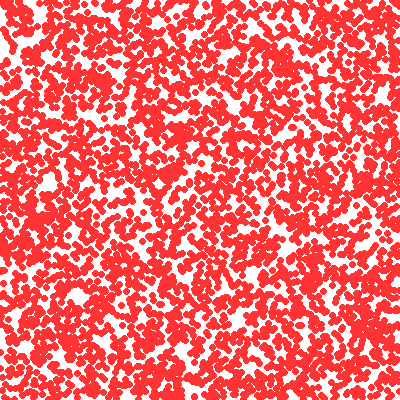
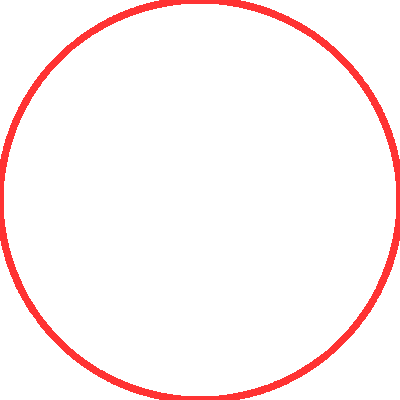

In [149]:
# Plot layout of nodes
tf.Images(nodesplot(randomlocs,"Random layout"), nodesplot(circularlocs, "Circular layout"))

In [151]:
#%time forcedirectedlocs = forceatlas2_layout(sampled_nodes, sampled_edges)

In [152]:
cd = circularlocs
rd = randomlocs

In [ ]:
%time cd_d = graphplot(cd, connect_edges(cd, sampled_edges), "Circular Layout")
%time rd_d = graphplot(rd, connect_edges(rd, sampled_edges), "Random Layout")

In [ ]:
tf.Images(cd_d,rd_d)